# Polymorphism analysis

## Inference of coding sequence based on variant calling data

*All the codes in this section are stored in scripts/coding_sequence_inferences folder.
The scripts were run at Pasteur HPC using packages installed there and not meant to be a stand alone package. For all python codes, run in RRRR_SNP_analysis2 environment in micromamba.*

Perform variant filtering for the GVCF file. Update the script accordingly to take variant data input file stored in variant_data folder.

> ./FilterVCF_JG_250827.sh

Get filtered variant data for each sample. e.g. for C1C5v2 run the following: 

> ./FilterVCF_JG_SW_250829.sh -i FilteredVCF_JG_250827/all_samples_hap_flexa_240723_set240924.combined.filtered.passed.sorted.vcf.gz -s C1C5v2 -d FilteredVCF_JG_SW_250829

Get variant sequences for each sample by runnging the following in the python environment and in the same directory as vcf2fasta package (install from https://github.com/yeeus/vcf2fasta). Make sure to locate C. flexa gebome gff3 file and filtered variant data in the correct directory

> ./run_JG_SW_vcf2fasta_250829.sh

Then, get fasta file for each gene aggregating inferred sequences from each strain

> python get_variant_seq_fasta.py --out_dir out/fasta_files_JG_SW_250829 --sample_dir_list out/C1G11_JG_SW_250829_CDS out/C1C5v2_JG_SW_250829_CDS out/C3D7v2_JG_SW_250829_CDS --include_ref True

vcf2fasta introduces * symbol in some sequences so remove them using the code below

> python remove_star_from_fasta.py --out_dir out/fasta_files_JG_SW_250829_NoStar --sample_list REF C1G11 C1C5v2 C3D7v2 --data_dir out/fasta_files_JG_SW_250829

Check if the gene length are multiple of 3, all have the same length, and no gaps is present in the sequence, count non-synonymous and synonymous mutations (mutations_df). Otherwise, list genes in genes_with_errors_file

> python get_mutations_df_from_fasta.py --fasta_dir out/fasta_files_JG_SW_250829_NoStar --df_mutations_dir out/mutations_df/JG_SW_250829_NoStar --genes_with_errors_file out/mutations_df/JG_SW_250829_NoStar_genes_with_errors.txt

Perform alignment for genes that did not satisfy the above condition. Use clustalo-omega program

> sbatch -J clustalo --array=1-5200%10 -c 50 -e clustalo/err/test_clustalo_arr_arg_%A_%a.err -o clustalo/out/test_clustalo_arr_arg_%A_%a.out test_clustalo_arr_arg.sh -t out/mutations_df/JG_SW_250829_NoStar_genes_with_errors.txt -d out/fasta_files_JG_SW_250829_NoStar -o clustalo/result/fasta_files_JG_SW_250829_NoStar

Convert fasta files to axt files as inputs for KaKs calculator

> python fasta2axt_gene_sets.py --initial_fasta_dir out/fasta_files_JG_SW_250829_NoStar --clustalo_fasta_dir clustalo/result/fasta_files_JG_SW_250829_NoStar --curated_fasta_dir out/fasta_files_JG_SW_250902_curated --out_axt_dir out/axt_files_JG_SW_250902


Check if the reference sequence recovered using vcf2fasta matches the reference sequence. If not, remove those genes from the analysis. 

> python scripts/coding_sequence_inferences/check_vcf2fasta.py --out_dir data/cds_inference --msa_data_dir /Users/uhoro/bio/pasteur/variant_calling/flexa/FilteredVCFs_250829/KaKs_high_JG_SW_250902_csv/fasta_files_JG_SW_250902_curated --ref_cds_file data/reference_genome_data/Cflexa.cds-transcripts.Hoceani_pruned.fa

Also, remove genes containing gaps whose lengths are not multiples of 3.

Record gaps in the fasta file used for KaKs analysis. Do this for all strains.
> python scripts/coding_sequence_inferences/record_gap_samples_fasta.py --out_dir data/cds_inference/gap_info --sampleid REF --data_dir /Users/uhoro/bio/pasteur/variant_calling/flexa/FilteredVCFs_250829/KaKs_high_JG_SW_250902_csv/fasta_files_JG_SW_250902_curated

Get all failed genes to be excluded from the downstream analysis
> python scripts/coding_sequence_inferences/get_failed_genes.py --out_dir data/cds_inference --cds_failed_fpath data/cds_inference/failed_cds.txt --gap_info_dir data/cds_inference/gap_info

## Non-synonymous substitutions analysis

*All scripts used in this section is stored in non_synonymous_substitutions_count folder.*


Count the number of non-synonymous substitutions for all genes.

Run batch_nonsyn_count.py to get non-synonymous substitutions count table for each gene.

Then, plot the result as a heatmap

pair:  C1C5v2_C3D7v2
Number of genes:  1561
pair:  C1G11_C3D7v2
Number of genes:  2698
pair:  C1G11_C1C5v2
Number of genes:  4049
pair:  No_NonSyn_substitutions
Number of genes:  3030


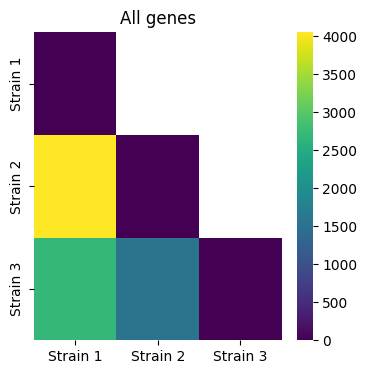

In [2]:
from helper_functions import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

PATH_TO_NON_SYN_COUNT = "/Users/uhoro/bio/pasteur/variant_calling/notebooks/250903_analysis/results/NonSyn_count_test"


ref_cds_file = "data/reference_genome_data/Cflexa.cds-transcripts.Hoceani_pruned.fa"
ref_sequences = {}
for record in SeqIO.parse(ref_cds_file , "fasta"):
    record_id = record.id.split("-")[0]
    ref_sequences[record_id] = str(record.seq)
all_gene_list = list(ref_sequences.keys())

# Read failed gene data
error_gene_fpath = "data/cds_inference/failed_genes_all.txt"
with open(error_gene_fpath) as f:
    genes_failed = [line.strip() for line in f.readlines()]

result_dict = {}
for geneid in all_gene_list:
    if geneid not in genes_failed:
        most_freq_pair = get_pair_w_most_nonsyn(geneid, result_folder = PATH_TO_NON_SYN_COUNT) 
        if most_freq_pair in result_dict.keys():
            result_dict[most_freq_pair].append(geneid)
        else:
            result_dict[most_freq_pair] = list()
            result_dict[most_freq_pair].append(geneid)
for pair in result_dict.keys():
    print("pair: ", pair)
    print("Number of genes: ", len(result_dict[pair]))
    
result_dict_all_gene = result_dict
Index= ["Strain 1", "Strain 2", "Strain 3"]
Cols = ["Strain 1", "Strain 2", "Strain 3"]
df_all = pd.DataFrame([
    [0, np.nan, np.nan],
    [len(result_dict_all_gene["C1G11_C1C5v2"]),0, np.nan],
    [len(result_dict_all_gene["C1G11_C3D7v2"]), len(result_dict_all_gene["C1C5v2_C3D7v2"]), 0]
], index = Index, columns = Cols)

f, axs = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

p1 = sns.heatmap(df_all,cmap="viridis",ax=axs)
axs.title.set_text('All genes')
#plt.savefig("results/Non_synonymous_substitutions_all_genes_heatmap.svg")

Plot genes with transmembrane domains

/var/folders/s9/cpzp3wfd7831nz97c48532140000gn/T/ipykernel_36242/2727806914.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  interpro_TM.loc[:,"geneid"] = interpro_TM.loc[:,"protein_id"].apply(get_geneid)


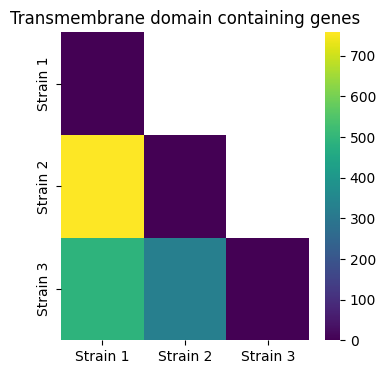

In [8]:
# Get genes with transmembrane domain in the gene list:
interpro_data = pd.read_csv("data/reference_genome_data/flexa2405_interproscan_out.csv")
interpro_TM = interpro_data.loc[interpro_data["signature_accession"] == "TRANSMEMBRANE",:]
def get_geneid(protein_id):
    return protein_id.split("-")[0]
interpro_TM.loc[:,"geneid"] = interpro_TM.loc[:,"protein_id"].apply(get_geneid)
geneid_w_TM = list(set(interpro_TM.loc[:,"geneid"]))
gene_dict_TM = {}
for key in result_dict_all_gene.keys():
    gene_dict_TM[key] = []
    for geneid in result_dict_all_gene[key]:
        if geneid in geneid_w_TM:
            gene_dict_TM[key].append(geneid)

df_TM = pd.DataFrame([
    [0, np.nan, np.nan],
    [len(gene_dict_TM["C1G11_C1C5v2"]),0, np.nan],
    [len(gene_dict_TM["C1G11_C3D7v2"]), len(gene_dict_TM["C1C5v2_C3D7v2"]), 0]
], index = Index, columns = Cols)

f, axs = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

p1 = sns.heatmap(df_TM,cmap="viridis",ax=axs)
axs.title.set_text('Transmembrane domain containing genes')
#plt.savefig("results/Non_synonymous_substitutions_only_TM_genes_heatmap.svg")

Non synonymous mutations for individual genes

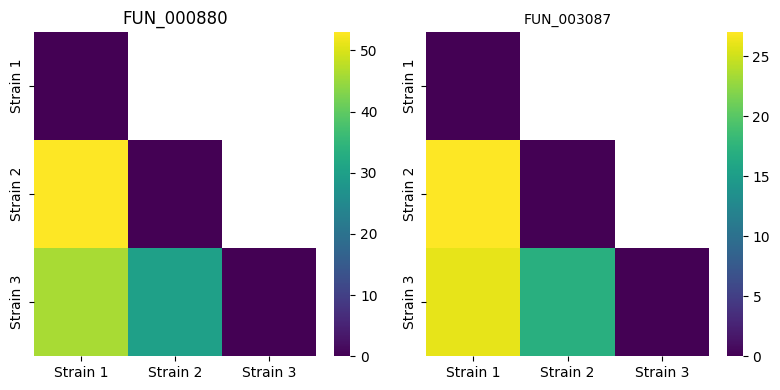

In [9]:
geneid2 = "FUN_000880"
fname = geneid2 + "_NonSyn_count.csv"
nonsyn_df = pd.read_csv(os.path.join(PATH_TO_NON_SYN_COUNT, fname))

df_geneid2 = pd.DataFrame([
    [nonsyn_df.loc[1, "C1G11"], np.nan, np.nan],
    [nonsyn_df.loc[2, "C1G11"], nonsyn_df.loc[2, "C1C5v2"], np.nan],
    [nonsyn_df.loc[3, "C1G11"], nonsyn_df.loc[3, "C1C5v2"], nonsyn_df.loc[3, "C3D7v2"]]
], index = Index, columns = Cols)


geneid3 = "FUN_003087"
fname = geneid3 + "_NonSyn_count.csv"
nonsyn_df = pd.read_csv(os.path.join(PATH_TO_NON_SYN_COUNT, fname))

df_geneid3 = pd.DataFrame([
    [nonsyn_df.loc[1, "C1G11"], np.nan, np.nan],
    [nonsyn_df.loc[2, "C1G11"], nonsyn_df.loc[2, "C1C5v2"], np.nan],
    [nonsyn_df.loc[3, "C1G11"], nonsyn_df.loc[3, "C1C5v2"], nonsyn_df.loc[3, "C3D7v2"]]
], index = Index, columns = Cols)

f, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

p2 = sns.heatmap(df_geneid2,cmap="viridis",ax=axs[0])
axs[0].title.set_text(geneid2)

p4 = sns.heatmap(df_geneid3,cmap="viridis",ax=axs[1])
axs[1].set_title(geneid3, fontsize=10)
plt.tight_layout()
#plt.savefig("results/Non_synonymous_substitutions_by_gene.svg")

## Computation of KaKs values for inferred genes and detection of high KaKs regions

*All the codes in this section are stored in scripts/KaKsCalculation folder.
The scripts were run at Pasteur HPC using packages installed there and not meant to be a stand alone package. For all python codes, run in RRRR_SNP_analysis2 environment in micromamba.*

Run KaKs calculator for sample pair combinations e.g. for C1G11 and C1C5v2 run the following:
Be sure to specify directory for java kakscalculator2 functions used to split sequences.

> sbatch -J pipe -c 4 -e KaKs_Pipeline_arg_test_JG_SW_250902.err -o KaKs_Pipeline_arg_test_JG_SW_250902.out KaKs_Pipeline_arg_test.sh -a KaKs_pipeline_data_250902/axt_files_JG_SW_250902 -i KaKs_pipeline_out_250902 -o KaKs_pipeline_result_250902/JG_SW_curated_all -x C1G11 -y C1C5v2

Run the following to get regions with high KaKs values.

> python concatenate_and_find_high_KaKs.py --kaks_dir KaKs_pipeline_result_250902/JG_SW_curated_all/C1G11_C1C5v2 --sample_pair C1G11_C1C5v2 --out_dir KaKs_high_JG_SW_250902_csv --all_kaks_csv_name split_114_6.axt.kaks.all --high_kaks_csv_name KaKs_high_C1G11_C1C5v2_JG_SW_250902.csv

## Interpro enrichment analysis on high KaKs genes

*All the codes in this section are stored in scripts/interpro_enrichment folder.
For all python codes, run in RRRR_SNP_analysis2 environment in micromamba.*

Update the reference interpro feature dataframe by running "IPR_gap_correction.R" script using the gap information of the reference gene after clustal-omega alignment.

> Rscript scripts/interpro_enrichment/IPR_gap_correction.R -d data/highKaKs_data -i data/reference_genome_data/flexa2405_interproscan_out.csv -r data/cds_inference/gap_info/REF_gaps.csv

Then, get interpro enrichment results by running get_highKaKs_ipr_enrichment_plot.R. Provide the high KaKs region result and the failed genes list to be excluded

> Rscript scripts/interpro_enrichment/get_highKaKs_ipr_enrichment_plot.R -x C1G11 -y C1C5v2 -d results -k data/highKaKs_data/KaKs_high_C1G11_C1C5v2_JG_SW_250902.csv -e data/cds_inference/failed_genes_all.txt -p data/highKaKs_data/flexa_IPS_corrected.csv

Visualise high KaKs gene abundance for all pairwose combinations of strains

C1G11_C1C5v2: 467 genes
C1G11_C3D7v2: 454 genes
C1C5v2_C3D7v2: 390 genes


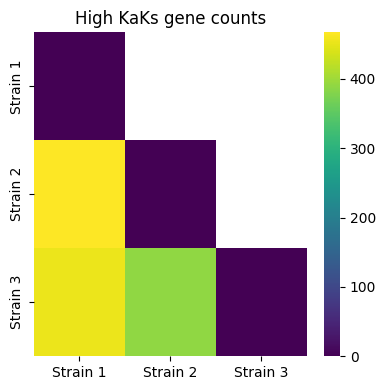

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Read high KaKs gene data
data_dir = "data/highKaKs_data"

C1G11_C1C5v2 = pd.read_csv(os.path.join(data_dir, "KaKs_high_C1G11_C1C5v2_JG_SW_250902.csv"))
C1G11_C3D7v2 = pd.read_csv(os.path.join(data_dir, "KaKs_high_C1G11_C3D7v2_JG_SW_250902.csv"))
C1C5v2_C3D7v2 = pd.read_csv(os.path.join(data_dir, "KaKs_high_C1C5v2_C3D7v2_JG_SW_250902.csv"))

# Read failed gene data
with open("data/cds_inference/failed_genes_all.txt") as f:
    genes_failed = [line.strip() for line in f.readlines()]

highKaKs_gene_dict = {}

highKaKs_gene_list = []
for i in range(len(C1G11_C1C5v2)):
    if (C1G11_C1C5v2.loc[i, "n_blocks2"] > 0) and (C1G11_C1C5v2.loc[i, "geneid"] not in genes_failed):
        highKaKs_gene_list.append(C1G11_C1C5v2.loc[i,"geneid"])
highKaKs_gene_dict["C1G11_C1C5v2"] = highKaKs_gene_list


highKaKs_gene_list = []
for i in range(len(C1G11_C3D7v2)):
    if (C1G11_C3D7v2.loc[i, "n_blocks2"] > 0) and (C1G11_C3D7v2.loc[i, "geneid"] not in genes_failed):
        highKaKs_gene_list.append(C1G11_C3D7v2.loc[i,"geneid"])
highKaKs_gene_dict["C1G11_C3D7v2"] = highKaKs_gene_list

highKaKs_gene_list = []
for i in range(len(C1C5v2_C3D7v2)):
    if (C1C5v2_C3D7v2.loc[i, "n_blocks2"] > 0) and (C1C5v2_C3D7v2.loc[i, "geneid"] not in genes_failed):
        highKaKs_gene_list.append(C1C5v2_C3D7v2.loc[i,"geneid"])
highKaKs_gene_dict["C1C5v2_C3D7v2"] = highKaKs_gene_list

for key in highKaKs_gene_dict.keys():
    print(f"{key}: {len(highKaKs_gene_dict[key])} genes")

Index= ["Strain 1", "Strain 2", "Strain 3"]
Cols = ["Strain 1", "Strain 2", "Strain 3"]
df_highKaKs = pd.DataFrame([
    [0, np.nan, np.nan],
    [len(highKaKs_gene_dict["C1G11_C1C5v2"]),0, np.nan],
    [len(highKaKs_gene_dict["C1G11_C3D7v2"]), len(highKaKs_gene_dict["C1C5v2_C3D7v2"]), 0]
], index = Index, columns = Cols)

f, axs = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

# p1 = sns.heatmap(df_all,cmap="viridis",ax=axs[0,0])
# axs[0,0].title.set_text('All genes')
p2 = sns.heatmap(df_highKaKs,cmap="viridis",ax=axs)
axs.title.set_text('High KaKs gene counts')

plt.tight_layout()
#plt.savefig("results/HighKaKs_for_all_pairs_heatmap.svg")

Get genes with transmembrane domain

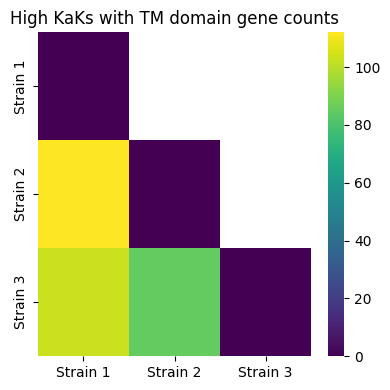

In [ ]:

interpro_data = pd.read_csv("data/highKaKs_data/flexa_IPS_corrected.csv")
interpro_TM = interpro_data.loc[interpro_data["signature_accession"] == "TRANSMEMBRANE",:]
geneid_w_TM = list(set(interpro_TM.loc[:,"geneid"]))
highKaKs_gene_dict_TM = {}
for key in highKaKs_gene_dict.keys():
    highKaKs_gene_dict_TM[key] = []
    for geneid in highKaKs_gene_dict[key]:
        if geneid in geneid_w_TM:
            highKaKs_gene_dict_TM[key].append(geneid)

Index= ["Strain 1", "Strain 2", "Strain 3"]
Cols = ["Strain 1", "Strain 2", "Strain 3"]
df_highKaKs_TM = pd.DataFrame([
    [0, np.nan, np.nan],
    [len(highKaKs_gene_dict_TM["C1G11_C1C5v2"]),0, np.nan],
    [len(highKaKs_gene_dict_TM["C1G11_C3D7v2"]), len(highKaKs_gene_dict_TM["C1C5v2_C3D7v2"]), 0]
], index = Index, columns = Cols)

f, axs = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

p2 = sns.heatmap(df_highKaKs_TM,cmap="viridis",ax=axs)
axs.title.set_text('High KaKs with TM domain gene counts')

plt.tight_layout()
#plt.savefig("results/HighKaKs_w_TM_for_all_pairs_heatmap.svg")